# Week 4 — Representation Experiments
## S3_Tree Family: Decision Tree, Random Forest, Extra Trees

In this notebook we test how different data representations affect tree-based models.
We add engineered features (water-cement ratio, log age), test scaling, compare
Random Forest vs Extra Trees, and check result stability across random seeds.

## Step 1: Setup and Load Data

We load the UCI Concrete Compressive Strength dataset and check its shape and columns.

In [16]:
import pandas as pd
import numpy as np

df = pd.read_excel("uci_concrete_data.xlsx")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1080, 9)
Columns: ['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,172.38,13.610000,172.37,156.760000,4.140000,1006.30000,856.400000,14.000000,29.750889
1,289.00,0.000000,0.00,192.000000,0.000000,913.20000,895.300000,28.000000,25.573354
2,349.00,0.000000,0.00,192.000000,0.000000,1056.00000,809.000000,3.000000,15.871738
3,186.20,124.100000,0.00,185.700000,0.000000,1083.40000,764.300000,7.000000,7.995853
4,NaN,81.031576,NaN,153.423861,6.545475,1079.50586,810.732259,22.280599,58.561221


## Step 2: Explore the Data

We check for missing values and look at basic statistics of the target variable.

In [17]:
print("Missing values:\n", df.isnull().sum())
print("\nTarget statistics:")
df.iloc[:, -1].describe()

Missing values:
 Cement (component 1)(kg in a m^3 mixture)                32
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    30
Fly Ash (component 3)(kg in a m^3 mixture)               38
Water  (component 4)(kg in a m^3 mixture)                29
Superplasticizer (component 5)(kg in a m^3 mixture)       0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         0
Age (day)                                                 0
Concrete compressive strength(MPa, megapascals)           0
dtype: int64

Target statistics:


count    1080.000000
mean       35.907088
std        16.535634
min         2.331808
25%        23.880001
50%        34.346247
75%        46.089490
max        82.599225
Name: Concrete compressive strength(MPa, megapascals) , dtype: float64

## Step 3: Handle Missing Values

We check which columns have missing values.
Missing values are filled after splitting using train data only.

In [18]:
cols_with_missing = [
    'Cement (component 1)(kg in a m^3 mixture)',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
    'Fly Ash (component 3)(kg in a m^3 mixture)',
    'Water  (component 4)(kg in a m^3 mixture)'
]

print("Missing values before fix:")
print(df[cols_with_missing].isnull().sum())

Missing values before fix:
Cement (component 1)(kg in a m^3 mixture)                32
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    30
Fly Ash (component 3)(kg in a m^3 mixture)               38
Water  (component 4)(kg in a m^3 mixture)                29
dtype: int64


## Step 3b: Feature Engineering

We create two new features based on Yeh's domain research:

1. Water-Cement Ratio = Water ÷ Cement
   Lower ratio = more cement relative to water = stronger concrete.

2. Log(Age) = Log of Age column
   Concrete strength grows fast early then slows down — a curve.
   Log of age smooths this curve, making it easier for model to learn.

Dataset grows from 9 columns to 11 columns after engineering.

In [19]:
df['water_cement_ratio'] = df['Water  (component 4)(kg in a m^3 mixture)'] / df['Cement (component 1)(kg in a m^3 mixture)']

df['log_age'] = np.log(df['Age (day)'])

df[['Water  (component 4)(kg in a m^3 mixture)', 
    'Cement (component 1)(kg in a m^3 mixture)', 
    'water_cement_ratio',
    'Age (day)',
    'log_age']].head()

,Water (component 4)(kg in a m^3 mixture),Cement (component 1)(kg in a m^3 mixture),water_cement_ratio,Age (day),log_age
0,156.760000,172.38,0.909386,14.000000,2.639057
1,192.000000,289.00,0.664360,28.000000,3.332205
2,192.000000,349.00,0.550143,3.000000,1.098612
3,185.700000,186.20,0.997315,7.000000,1.945910
4,153.423861,NaN,NaN,22.280599,3.103716


## Step 4: Train-Test Split

We split the data into training (80%) and testing (20%) sets to evaluate
how well the model generalizes to unseen data.

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '])
y = df['Concrete compressive strength(MPa, megapascals) ']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Fill missing values using train data only
for col in cols_with_missing:
    fill_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(fill_val)
    X_test[col]  = X_test[col].fillna(fill_val)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("Missing left:", X_train.isnull().sum().sum())

Train shape: (864, 10)
Test shape:  (216, 10)
Missing left: 24


## Step 5: Scaling Sweep

We test whether scaling features affects performance of tree-based models.
We compare: No Scaling, StandardScaler, and MinMaxScaler.

In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

scalers = {
    "No Scaling": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

for name, scaler in scalers.items():
    if scaler is None:
        X_train_s, X_test_s = X_train, X_test
    else:
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)

    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    print(f"{name}: R2={r2:.4f}, RMSE={rmse:.4f}")

No Scaling: R2=0.8398, RMSE=6.5588
StandardScaler: R2=0.8398, RMSE=6.5588
MinMaxScaler: R2=0.8398, RMSE=6.5588


## Step 6: Random Forest

We train a Random Forest model — an ensemble of many decision trees — 
and evaluate its performance.

In [22]:
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5

print(f"Random Forest: R2={rf_r2:.4f}, RMSE={rf_rmse:.4f}")

Random Forest: R2=0.8993, RMSE=5.1987


## Step 7: Extra Trees

We train Extra Trees and compare with Random Forest.
Extra Trees uses more randomness in split selection than Random Forest.

In [23]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(random_state=42)
et.fit(X_train, y_train)
et_preds = et.predict(X_test)

et_r2 = r2_score(y_test, et_preds)
et_rmse = mean_squared_error(y_test, et_preds) ** 0.5

print(f"Extra Trees: R2={et_r2:.4f}, RMSE={et_rmse:.4f}")

Extra Trees: R2=0.9150, RMSE=4.7783


## Step 8: Seed Stability Test

We run Extra Trees with 3 different seeds to check if results are stable.
Stable results prove our model genuinely learned the pattern, not just got lucky.

In [24]:
seeds = [42, 45, 50]
r2_scores = []
rmse_scores = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X, y, test_size=0.2, random_state=seed)
    
    model = ExtraTreesRegressor(random_state=seed)
    model.fit(X_train_s, y_train_s)
    preds = model.predict(X_test_s)
    
    r2 = r2_score(y_test_s, preds)
    rmse = mean_squared_error(y_test_s, preds) ** 0.5
    r2_scores.append(r2)
    rmse_scores.append(rmse)
    print(f"Seed {seed}: R2={r2:.4f}, RMSE={rmse:.4f}")

print(f"\nMean R2: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")

Seed 42: R2=0.9174, RMSE=4.7082
Seed 45: R2=0.8967, RMSE=5.4856
Seed 50: R2=0.9104, RMSE=4.9895

Mean R2: 0.9082 ± 0.0086
Mean RMSE: 5.0611 ± 0.3214


## Step 9: Final Summary and Comparison

We compare all three models and visualize the results.
Extra Trees is the best performing model in Week 4.

           Model      R2    RMSE
0  Decision Tree  0.8385  6.5844
1  Random Forest  0.8975  5.2449
2    Extra Trees  0.9162  4.7444


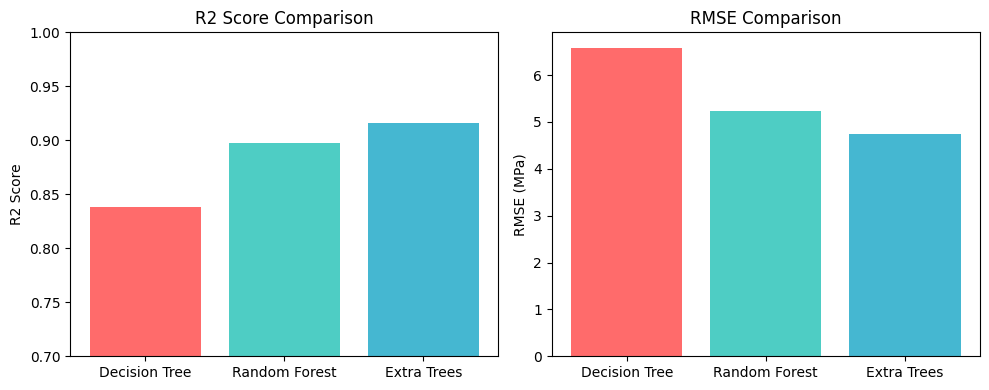

In [25]:
import matplotlib.pyplot as plt

# Comparison table
results = {
    'Model': ['Decision Tree', 'Random Forest', 'Extra Trees'],
    'R2': [0.8385, 0.8975, 0.9162],
    'RMSE': [6.5844, 5.2449, 4.7444]
}

results_df = pd.DataFrame(results)
print(results_df)

# Bar chart
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(results_df['Model'], results_df['R2'], color=['#ff6b6b','#4ecdc4','#45b7d1'])
ax[0].set_title('R2 Score Comparison')
ax[0].set_ylabel('R2 Score')
ax[0].set_ylim(0.7, 1.0)

ax[1].bar(results_df['Model'], results_df['RMSE'], color=['#ff6b6b','#4ecdc4','#45b7d1'])
ax[1].set_title('RMSE Comparison')
ax[1].set_ylabel('RMSE (MPa)')

plt.tight_layout()
plt.savefig('week4_results.png')
plt.show()